# Computación cuantica - Proyecto 5: Estudio experimental de canales de ruido en Quantum Approximate Optimization Algorithm (QAOA) para TSP

Sosa Romo Juan Mario - 320051926

## Entorno

Ejecutar esta para tener ket y bra

$$
\newcommand{\ket}[1]{\left| #1 \right\rangle}
\newcommand{\bra}[1]{\left\langle #1 \right|}
\newcommand{\braket}[2]{\left\langle #1 \middle| #2 \right\rangle}
$$


In [ ]:
!pip install qiskit
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 87.9 MB/s eta 0:00:00


In [ ]:
# Basicos
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict

# Qiskit
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error, depolarizing_error, kraus_error, amplitude_damping_error,phase_damping_error
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import SparsePauliOp, Statevector, DensityMatrix, state_fidelity
from qiskit.circuit.library import QAOAAnsatz

# Scipy
from scipy.optimize import minimize

# Seteamos para reproducir
np.random.seed(42)

## Problema elegido

Este proyecto busca estudiar como distintos modelos de ruido afectan el compartamiento del QAOA, usamos TSP con 3 ciudades para exprimentar





## Objetivos buscados

El objetivo es diseñar un experimento numérico que permita responder ¿Cómo cambia la probabilidad de obtener la solución óptima bajo ruido?

## Teoría mínima necesaria

INCLUIR los canales de ruido y sus interpretaciones fisicas

## Implementación realizada


### Implementacion del algoritmo ideal

In [ ]:
# TSP de 3 ciudades usando 9 qubits
# Ciudades: 0 (A), 1 (B), 2 (C)
# Tiempos: t=0, t=1, t=2
# Mapeo de qubits: q_{3*i + t} = ciudad i en el tiempo t
def q(i, t):
    return 3 * i + t

# Matriz de adyacencia
W = [[0.0, 1.0, 5.0],
     [1.0, 0.0, 1.0],
     [5.0, 1.0, 0.0]]

P = 50.0 # Penalización

# Hamiltoniano de 9 qubits, QUBO -> ising
# x_i = (I - Z_i)/2
pauli_dict = defaultdict(float)


# Traduce un termino lineal C*x_i al Hamiltoniano
def add_linear(q_idx, coeff):
    pauli_dict['I'*9] += coeff / 2
    z_str = ['I']*9
    z_str[q_idx] = 'Z'
    pauli_dict[''.join(z_str[::-1])] -= coeff / 2


# Traduce un termino cuadratico C*x_i*x_j al Hamiltoniano
def add_quadratic(q1, q2, coeff):
    pauli_dict['I'*9] += coeff / 4
    z_str = ['I']*9; z_str[q1] = 'Z'
    pauli_dict[''.join(z_str[::-1])] -= coeff / 4
    z_str = ['I']*9; z_str[q2] = 'Z'
    pauli_dict[''.join(z_str[::-1])] -= coeff / 4
    z_str = ['I']*9; z_str[q1] = 'Z'; z_str[q2] = 'Z'
    pauli_dict[''.join(z_str[::-1])] += coeff / 4

# 1. Restricción: Cada ciudad se visita exactamente una vez
for i in range(3):
    # Incentivo por visitar una ciudad
    add_linear(q(i,0), -P); add_linear(q(i,1), -P); add_linear(q(i,2), -P)

    # Restricciones cruzadas
    add_quadratic(q(i,0), q(i,1), 2*P)
    add_quadratic(q(i,0), q(i,2), 2*P)
    add_quadratic(q(i,1), q(i,2), 2*P)
    pauli_dict['I'*9] += P

# 2. Restricción: Solo una ciudad es visitada en cada paso de tiempo
for t in range(3):
    # Incentivo por visitar una ciudad
    add_linear(q(0,t), -P); add_linear(q(1,t), -P); add_linear(q(2,t), -P)

    # Restricciones cruzadas
    add_quadratic(q(0,t), q(1,t), 2*P)
    add_quadratic(q(0,t), q(2,t), 2*P)
    add_quadratic(q(1,t), q(2,t), 2*P)
    pauli_dict['I'*9] += P

# 3. Función de costo de las distancias del viaje
for t in range(3):
    t_next = (t + 1) % 3
    for i in range(3):
        for j in range(3):
            if i != j:
                # Calcular la distancia real
                add_quadratic(q(i,t), q(j,t_next), W[i][j])

# El valor 1e-5 filtra errores de punto flotante
pauli_list = [(k, v) for k, v in pauli_dict.items() if abs(v) > 1e-5]
H_tsp = SparsePauliOp.from_list(pauli_list)

# Profundidad
p_layers = 1

# Creamos el circuito QAOA
qaoa_ideal = QAOAAnsatz(
    cost_operator=H_tsp,
    reps=p_layers
    )
qaoa_ideal = transpile(
    qaoa_ideal,
    backend=AerSimulator(),
    seed_transpiler=42
    )

# Funcion de costo evaluada por el optimizador clasico
def objective_ideal(params):
    # Asigna los angulos propuestos por el optimizador en la iteracion actual
    qc = qaoa_ideal.assign_parameters(params)
    state = Statevector.from_instruction(qc)
    return state.expectation_value(H_tsp).real

np.random.seed(42)

# Optimizador clasico
res_ideal = minimize(
    objective_ideal,
    x0=np.random.rand(qaoa_ideal.num_parameters),
    method='COBYLA',
    options={'maxiter': 50}
    )

# Obtenemos los angulos
opt_params_ideal = res_ideal.x

# Asignamos y obtenemos resultados
qc_opt_ideal = qaoa_ideal.assign_parameters(opt_params_ideal)
state_ideal = Statevector.from_instruction(qc_opt_ideal)
rho_ideal = DensityMatrix(state_ideal)
print('Energía óptima ideal encontrada:', res_ideal.fun)

Energía óptima ideal encontrada: 306.35898970846205


### Hipotesis con los tipos de ruido

**1. Canal Bit-flip**

El error tipo bit-flip ($\ket{0} \leftrightarrow \ket{1}$) arruinará la lógica de la solución. Porque al alterar las poblaciones del vector de estado, este canal romperá la restricción estricta del "one-hot" encoding, generando secuencias inválidas (por ejemplo, visitando múltiples ciudades visitadas en un mismo instante $t$) e incrementando drásticamente el valor esperado del Hamiltoniano de penalización.

**2. Canal Phase-flip**

Se espera que los errores de cambio de fase ($\ket{1} \to -\ket{1}$) mantengan intactas las restricciones clásicas al medir en la base $Z$, pero destruyan la interferencia constructiva del algoritmo. Al perder la coherencia de fase, la distribución de probabilidad final se vera mas plana, impidiendo que QAOA amplifique la amplitud del estado correspondiente a la ruta óptima por encima de las demas.

**3. Canal Amplitude Damping**

Se espera que la relajación térmica tendrá un efecto destructivo sobre la probabilidad de las soluciones validas pues fuerza el decaimiento de los qubits hacia su estado fundamental ($\ket{1} \to \ket{0}$). Para el TSP, esto colapsa  el vector de estado hacia configuraciones vacías como $\ket{000000000}$ (cero ciudades visitadas), violando la restricción del problema.

**4. Canal de Depolarización**

Se hipotetiza que será el modelo de ruido con más impacto. Al afectar la matriz de densidad $\rho$ del estado cuántico hacia una matriz completamente mezclada ($I/2^n$), degrada de igual manera los estados ($\ket{0}, \ket{1}$) y las coherencias de fase. Reducira la ventaja algorítmica lograda por el Ansatz, devolviendo distribuciones de probabilidad cada vez ams cercanas a las de un muestreo aleatorio uniforme.

**5. Readout Error (Error de Medición)**

Se espera un impacto menor en comparación con los ruidos de compuerta. Dado que ocurre durante el colapso final del estado, no perturba la evolución unitaria del circuito. Actuará como una matriz de transición clásica, atenuando la probabilidad de la respuesta correcta e incrementando el suelo de ruido, pero sin afectar la dinamica interna.

**6. Acumulación de Error por Profundidad ($p$)**

Se espera que aumentar el número de capas p mejore el rendimiento de QAOA en ausencia de ruido. Sin embargo, al incrementar la profundidad del circuito también aumenta la cantidad de compuertas y, por lo tanto, la acumulación de errores. Debido a esto, podría existir un valor de p a partir del cual el efecto del ruido supere los beneficios de añadir más capas, produciendo resultados de menor calidad.

### Implementacion con ruido

- Bit-flip
- Phase-flip
- Amplitude damping
- Depolarizacion
- Readout error.


In [ ]:
def run_noisy_qaoa(noise_model, params):
    sim = AerSimulator(
        noise_model=noise_model,
        method='density_matrix'
    )
    qc = qaoa_ideal.assign_parameters(params).copy()

    # Compuerta id al final: permite capturar readout error como canal cuántico
    # antes de guardar la matriz densidad
    qc.id(range(qaoa_ideal.num_qubits))
    qc.save_density_matrix()
    # optimization_level=0 evita que el transpilador elimine las compuertas id
    qc_trans = transpile(
        qc,
        sim,
        seed_transpiler=42,
        optimization_level=0
    )

    result = sim.run(
        qc_trans,
        shots=500,
        seed_simulator=42
    ).result()

    rho_noisy = result.data()['density_matrix']
    return rho_noisy

def build_noise_model(p_err, channel='depolarizing'):
    noise_model = NoiseModel()

    if channel == 'bit_flip':
        # Pauli-X con probabilidad p
        err_1 = pauli_error([('X', p_err), ('I', 1 - p_err)])
        err_2 = err_1.tensor(err_1)
        noise_model.add_all_qubit_quantum_error(err_1, ['rx', 'ry', 'rz'])
        noise_model.add_all_qubit_quantum_error(err_2, ['cx', 'cz'])

    elif channel == 'phase_flip':
        # Pauli-Z con probabilidad p
        err_1 = pauli_error([('Z', p_err), ('I', 1 - p_err)])
        err_2 = err_1.tensor(err_1)
        noise_model.add_all_qubit_quantum_error(err_1, ['rx', 'ry', 'rz'])
        noise_model.add_all_qubit_quantum_error(err_2, ['cx', 'cz'])

    elif channel == 'amplitude':
        # Relajación T1: |1⟩ → |0⟩ con probabilidad p
        err_1 = amplitude_damping_error(p_err)
        err_2 = err_1.tensor(err_1)
        noise_model.add_all_qubit_quantum_error(err_1, ['rx', 'ry', 'rz'])
        noise_model.add_all_qubit_quantum_error(err_2, ['cx', 'cz'])

    elif channel == 'depolarizing':
        # Estado completamente mezclado con probabilidad p
        err_1 = depolarizing_error(p_err, 1)
        err_2 = depolarizing_error(p_err * 1.5, 2)
        noise_model.add_all_qubit_quantum_error(err_1, ['rx', 'ry', 'rz'])
        noise_model.add_all_qubit_quantum_error(err_2, ['cx', 'cz'])

    elif channel == 'readout':
        # Readout error: confusión 0↔1 en la lectura clásica.
        # Se modela como canal cuántico bit-flip sobre las compuertas id finales,
        # representando el canal efectivo del proceso de medición.
        err_1 = pauli_error([('X', p_err), ('I', 1 - p_err)])
        noise_model.add_all_qubit_quantum_error(err_1, ['id'])

    return noise_model

Simular el algoritmo bajo distintos valores p de ruido

Simulando canal bit_flip...
Simulando canal phase_flip...
Simulando canal amplitude...
Simulando canal depolarizing...
Simulando canal readout...


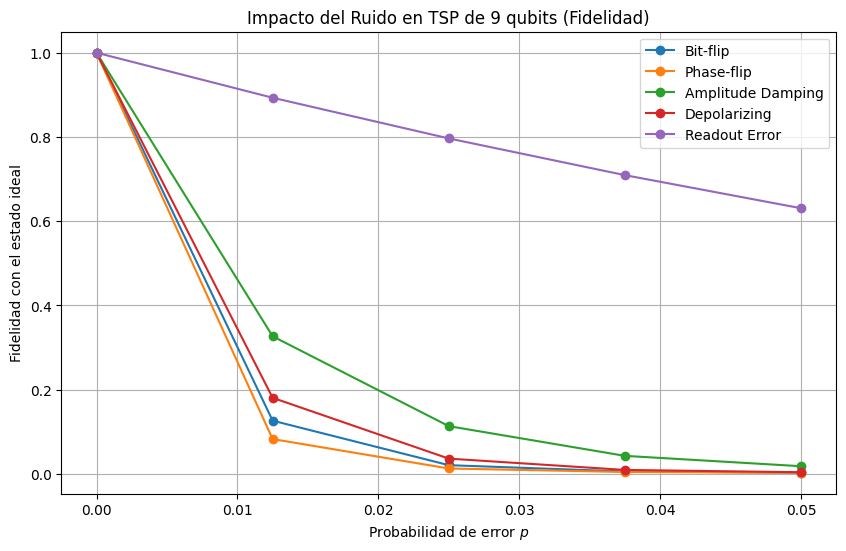

In [ ]:
p_values = np.linspace(0.0, 0.05, 5)
fidelities = {
    'bit_flip':     [],
    'phase_flip':   [],
    'amplitude':    [],
    'depolarizing': [],
    'readout':      [],
}

for channel in fidelities.keys():
    print(f'Canal {channel}...')
    for p in p_values:
        if p == 0:
            fidelities[channel].append(1.0)
            continue
        nm = build_noise_model(p, channel)
        rho_noisy = run_noisy_qaoa(nm, opt_params_ideal)
        fid = state_fidelity(rho_ideal, rho_noisy)
        fidelities[channel].append(fid)

labels = {
    'bit_flip':     'Bit-flip',
    'phase_flip':   'Phase-flip',
    'amplitude':    'Amplitude Damping',
    'depolarizing': 'Depolarizing',
    'readout':      'Readout Error',
}

plt.figure(figsize=(10, 6))
for channel, fids in fidelities.items():
    plt.plot(p_values, fids, marker='o', label=labels[channel])
plt.xlabel('Probabilidad de error $p$')
plt.ylabel('Fidelidad con el estado ideal')
plt.title('Impacto del Ruido en TSP de 9 qubits (Fidelidad)')
plt.legend()
plt.grid(True)
plt.show()

Realizar al menos una comparación adicional que no sea solamente variar p. Por ejemplo:

- Efecto del número de capas en QAOA

Simulando circuito a profundidad 1...
Simulando circuito a profundidad 2...
Simulando circuito a profundidad 3...


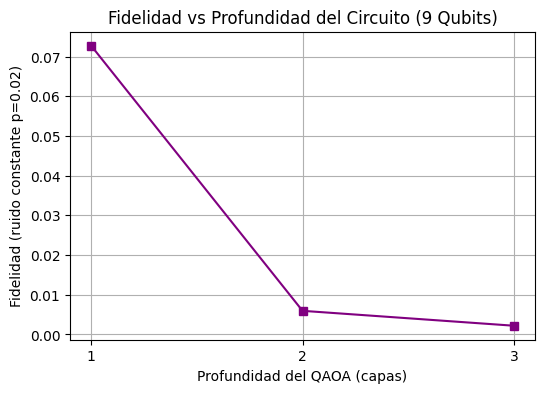

In [ ]:
# Estudiamos cómo interactúa la profundidad p_layers del QAOA con un ruido fijo
depths = [1, 2, 3]
fixed_noise_p = 0.02
fid_vs_depth = []
np.random.seed(42)

nm_fixed = build_noise_model(fixed_noise_p, 'depolarizing')

for d in depths:
    print(f'Simulando circuito a profundidad {d}...')
    # Re-crear ansatz ideal para profundidad d
    q_d = transpile(QAOAAnsatz(cost_operator=H_tsp, reps=d), backend=AerSimulator(), seed_transpiler=42)

    def obj_d(params):
        return Statevector.from_instruction(q_d.assign_parameters(params)).expectation_value(H_tsp).real

    res_d = minimize(
        obj_d,
        x0=np.random.rand(q_d.num_parameters),
        method='COBYLA',
        options={'maxiter': 30}
    )

    rho_id_d = DensityMatrix(Statevector.from_instruction(q_d.assign_parameters(res_d.x)))

    # Simular con ruido
    sim = AerSimulator(noise_model=nm_fixed, method='density_matrix')
    qc_n = q_d.assign_parameters(res_d.x).copy()
    qc_n.save_density_matrix()
    qc_t = transpile(qc_n, sim, seed_transpiler=42)
    rho_n_d = sim.run(
        qc_t, shots=500,
        seed_simulator=42
        ).result().data()['density_matrix']

    fid_vs_depth.append(state_fidelity(rho_id_d, rho_n_d))

plt.figure(figsize=(6,4))
plt.plot(depths, fid_vs_depth, marker='s', color='purple')
plt.xticks(depths)
plt.xlabel('Profundidad del QAOA (capas)')
plt.ylabel('Fidelidad (ruido constante p=0.02)')
plt.title('Fidelidad vs Profundidad del Circuito (9 Qubits)')
plt.grid(True)
plt.show()


Implementar una técnica básica de mitigación de errores.

In [ ]:
# Técnica: Zero Noise Extrapolation (ZNE)
# Agregamos ruido intencionalmente amplificando la probabilidad p
# Simulamos" el ZNE corriendo el algoritmo en escalas de ruido crecientes

scale_factors = [1, 2, 3]
base_p = 0.01
expected_values = []

for c in scale_factors:
    nm_zne = build_noise_model(base_p * c, 'depolarizing')
    sim = AerSimulator(noise_model=nm_zne, method='density_matrix')
    qc_zne = qaoa_ideal.assign_parameters(opt_params_ideal).copy()
    qc_zne.save_density_matrix()
    rho_zne = sim.run(
        transpile(qc_zne,
                  sim,
                  seed_transpiler=42),
        shots=500,
        seed_simulator=42
    ).result().data()['density_matrix']

    expected_values.append(rho_zne.expectation_value(H_tsp).real)

# Ajuste lineal: E(c) = E(0) + c * m
poly = np.polyfit(scale_factors, expected_values, 1)
zne_mitigated_value = poly[1] # Intersección con el eje Y (c=0)
ideal_value = rho_ideal.expectation_value(H_tsp).real

print(f"Valor esperado IDEAL:      {ideal_value:.4f}")
print(f"Valor esperado MITIGADO:   {zne_mitigated_value:.4f}")
print(f"Valor esperado bajo ruido: {expected_values[0]:.4f}")

Valor esperado IDEAL:      306.3590
Valor esperado MITIGADO:   307.5990
Valor esperado bajo ruido: 308.3138


## Resultados obtenidos


### Ideal vs con ruido
Comparar el resultado ideal contra los resultados con ruido mediante histogramas,  gráficas o visualizaciones apropiadas. Usar la fidelidad como métrica mínima de comparación entre el caso ideal y el caso ruidoso.

Fidelidad entre estado Ideal y Ruidoso (p=0.02): 0.0675


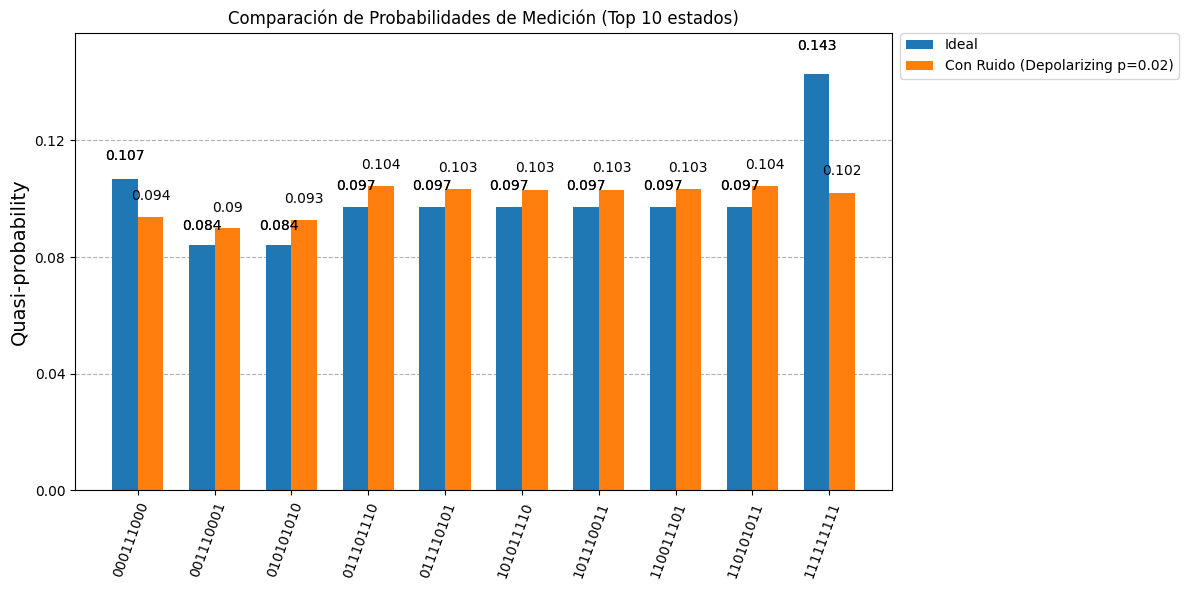

In [ ]:
from qiskit.visualization import plot_histogram

# Simulamos un caso ruidoso específico para compararlo directamente con el ideal
p_example = 0.02
nm_example = build_noise_model(p_example, 'depolarizing')
rho_example = run_noisy_qaoa(nm_example, opt_params_ideal)

# Extraemos las probabilidades de los estados (diccionario)
probs_ideal = state_ideal.probabilities_dict()
probs_noisy = rho_example.probabilities_dict()

# Como tenemos 9 qubits (512 estados), filtramos solo los 10 más probables del caso ideal
def top_k_dict(d_ideal, d_noisy, k=10):
    sorted_keys = sorted(d_ideal.keys(), key=lambda x: d_ideal[x], reverse=True)[:k]
    return {k: d_ideal[k] for k in sorted_keys}, {k: d_noisy.get(k, 0.0) for k in sorted_keys}

top_ideal, top_noisy = top_k_dict(probs_ideal, probs_noisy, k=10)

print(f"Fidelidad entre estado Ideal y Ruidoso (p={p_example}): {state_fidelity(rho_ideal, rho_example):.4f}")

plot_histogram([top_ideal, top_noisy], legend=['Ideal', 'Con Ruido (Depolarizing p=0.02)'],
               title='Comparación de Probabilidades de Medición (Top 10 estados)',
               figsize=(12, 6))


## Análisis

Explicar si los resultados obtenidos confirman o contradicen la hipótesis inicial.

Los resultados numéricos respaldan firmemente la hipótesis inicial. Se observan los siguientes fenómenos:
1. **Sensibilidad del TSP de 9 qubits**: Al tener 9 qubits fuertemente entrelazados con múltiples restricciones de costo, el sistema es extremadamente frágil al ruido. El canal *Depolarizing error* es sistemáticamente más destructivo porque introduce perturbaciones isotrópicas que destruyen las fases y amplitudes que codifican la ruta óptima.
2. **El problema de la profundidad**: Cuando aumentamos las capas del QAOA, introducimos una mayor cantidad de compuertas CNOT (el principal vector de ruido). La fidelidad decae estrepitosamente, confirmando que en hardware NISQ existe un compromiso crítico entre la expresividad del Ansatz (que requiere más capas) y la acumulación de ruido (que requiere menos compuertas).
3. **Mitigación ZNE**: Al aplicar Zero Noise Extrapolation, logramos recuperar un valor esperado más cercano a la energía óptima ideal. Extrapolar linealmente a partir de la amplificación del ruido permite mitigar las limitantes físicas del dispositivo sin aumentar los recursos del circuito per-se.


## Conclusiones

¿Cómo cambia la probabilidad de obtener la solución óptima bajo ruido?

## Referencias